In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import drawdata

import matplotlib.pyplot as plt

In [14]:
widget = drawdata.ScatterWidget()
widget

In [21]:
data = widget.data_as_pandas

In [22]:
data.shape

(189, 5)

In [23]:
data.head()

,x,y,color,label,batch
0,122.964391,163.460921,#1f77b4,a,0
1,139.089095,163.454884,#1f77b4,a,0
2,125.784810,202.419428,#1f77b4,a,0
3,102.239905,210.986236,#1f77b4,a,0
4,133.296074,207.270043,#1f77b4,a,0


In [40]:
data.to_csv('datasets/simple.csv', index=False)

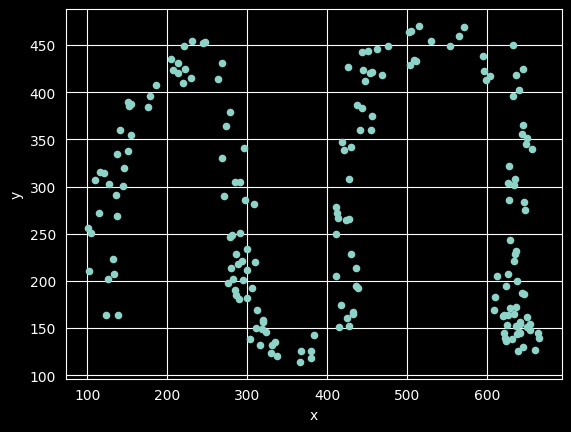

In [46]:
fig, ax = plt.subplots()

data.plot.scatter(x='x', y='y', ax=ax)

plt.show()

# Explore Bagging

6 different random forest with a single tree

In [17]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor

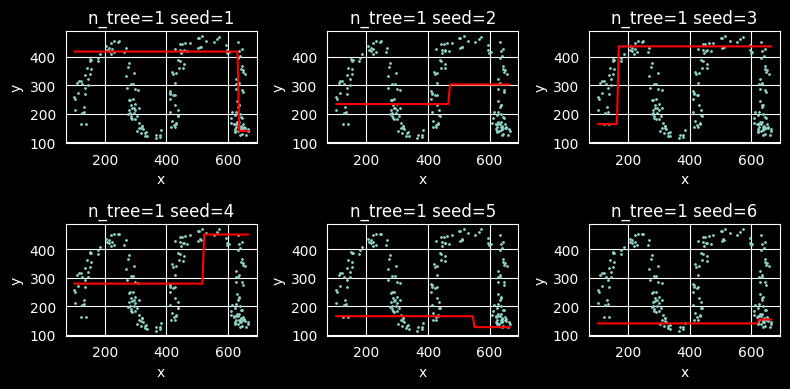

In [18]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1] * 6

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree} seed={i}', s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=i)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.predict(x)

    ax.plot(x, y, c='red')

fig.tight_layout()


In [25]:
np.linspace(0, 20, 100)

array([ 0.        ,  0.2020202 ,  0.4040404 ,  0.60606061,  0.80808081,
        1.01010101,  1.21212121,  1.41414141,  1.61616162,  1.81818182,
        2.02020202,  2.22222222,  2.42424242,  2.62626263,  2.82828283,
        3.03030303,  3.23232323,  3.43434343,  3.63636364,  3.83838384,
        4.04040404,  4.24242424,  4.44444444,  4.64646465,  4.84848485,
        5.05050505,  5.25252525,  5.45454545,  5.65656566,  5.85858586,
        6.06060606,  6.26262626,  6.46464646,  6.66666667,  6.86868687,
        7.07070707,  7.27272727,  7.47474747,  7.67676768,  7.87878788,
        8.08080808,  8.28282828,  8.48484848,  8.68686869,  8.88888889,
        9.09090909,  9.29292929,  9.49494949,  9.6969697 ,  9.8989899 ,
       10.1010101 , 10.3030303 , 10.50505051, 10.70707071, 10.90909091,
       11.11111111, 11.31313131, 11.51515152, 11.71717172, 11.91919192,
       12.12121212, 12.32323232, 12.52525253, 12.72727273, 12.92929293,
       13.13131313, 13.33333333, 13.53535354, 13.73737374, 13.93

# random forest vs single tree

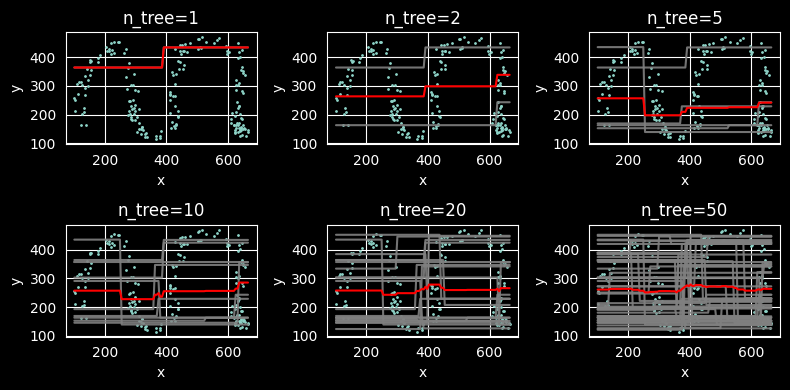

In [19]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree}', s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=42)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    for i, tree in enumerate(clf.estimators_):
        y = tree.predict(x)
        ax.plot(x, y, c='gray', alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c='red')

fig.tight_layout()


In [22]:
from ipywidgets import interact, IntSlider, FloatSlider

In [23]:
def plot_random_forest(data_path, max_depth, max_samples):
    layouts = """
    123
    456
    """


    plt.close('all')

    fig, axs = plt.subplot_mosaic(layouts, figsize=(8, 4))
    n_trees = [1, 2, 5, 10, 20, 50]

    data = pd.read_csv(data_path)

    for i, n_tree in enumerate(n_trees, start=1):
        ax = axs[str(i)]

        data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree} seed={i}', s=1)

        clf = RandomForestRegressor(n_estimators=n_tree, max_depth=max_depth, max_samples=max_samples, random_state=42)
        clf.fit(data[['x']], data['y'])

        x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
        })

        for i, tree in enumerate(clf.estimators_):
            y = tree.predict(x)
            ax.plot(x, y, c='gray', alpha=0.9)

        y = clf.predict(x)
        ax.plot(x, y, c='red')

    fig.tight_layout()
    plt.show()


In [24]:
max_depth_slider = IntSlider(min=1, max=10, value=3, description='Max depth')
max_samples_slider = FloatSlider(min=0.01, max=1.0, step=0.01 , value=0.1, description='Max Sample' )

interact(
    plot_random_forest,
    data_path='datasets/simple.csv',
    max_depth=max_depth_slider,
    max_samples=max_samples_slider
)

<function __main__.plot_random_forest(data_path, max_depth, max_samples)>

---

In [25]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn import set_config

In [26]:
set_config(transform_output='pandas')

In [27]:
adult_data = fetch_openml(data_id=1590)
X = adult_data.data
y = adult_data.target

In [4]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [5]:
y.head()

0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, object): ['<=50K', '>50K']

In [6]:
type(adult_data)

sklearn.utils._bunch.Bunch

In [28]:
(
    X
    .assign(y=y)
    .to_parquet('datasets/adult_copy.parquet')
)

In [29]:
adult = pd.read_parquet('datasets/adult.parquet')
X = adult.drop(columns='y')
y = adult.y

In [30]:
X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [32]:
categorical_features = X.select_dtypes(include=['category']).columns
categorical_transformer = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [33]:
categorical_transformer.fit_transform(X.iloc[:, :2])

,age_17,age_18,age_19,age_20,age_21,age_22,age_23,age_24,age_25,age_26,...,age_90,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48840,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [26]:
categorical_transformer.fit_transform(X[categorical_features])

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing,education_10th,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_missing
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48838,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48839,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48840,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [30]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [31]:
predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.818


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.832


In [54]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_distributions = {
    "classifier__n_estimators": np.arange(50, 801, 50),
    "classifier__max_depth": [None, 3, 5, 8, 12, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None],
}

rnd = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

rnd.fit(X_train, y_train)

print("Best params:", rnd.best_params_)
print("Best CV accuracy:", rnd.best_score_)

y_pred = rnd.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

pd.DataFrame(rnd.cv_results_).sort_values("rank_test_score").head(10)[
    ["mean_test_score", "std_test_score", "mean_train_score", "params"]
]

Best params: {'classifier__n_estimators': np.int64(300), 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': None}
Best CV accuracy: 0.8317588223977692
Test accuracy: 0.8325257626424623


,mean_test_score,std_test_score,mean_train_score,params
27,0.831759,0.002541,0.834245,"{'classifier__n_estimators': 300, 'classifier_..."
23,0.830881,0.004376,0.840928,"{'classifier__n_estimators': 600, 'classifier_..."
12,0.830794,0.003973,0.844943,"{'classifier__n_estimators': 650, 'classifier_..."
24,0.830677,0.004539,0.840841,"{'classifier__n_estimators': 800, 'classifier_..."
28,0.830501,0.003968,0.840855,"{'classifier__n_estimators': 400, 'classifier_..."
11,0.830384,0.002902,0.834208,"{'classifier__n_estimators': 650, 'classifier_..."
0,0.830209,0.005714,0.846895,"{'classifier__n_estimators': 750, 'classifier_..."
22,0.830062,0.004072,0.837294,"{'classifier__n_estimators': 150, 'classifier_..."
26,0.829273,0.004502,0.849030,"{'classifier__n_estimators': 50, 'classifier__..."
1,0.828746,0.003267,0.831920,"{'classifier__n_estimators': 150, 'classifier_..."


# Boosting and Gradient Boosting

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings('ignore')

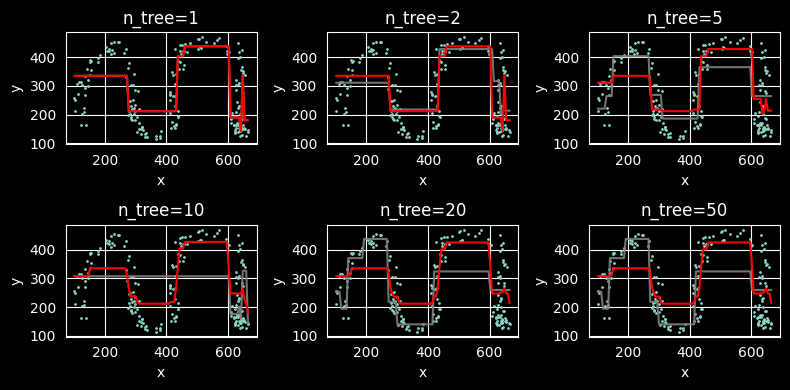

In [40]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree}', s=1)

    clf = AdaBoostRegressor(n_estimators=n_tree, estimator=DecisionTreeRegressor(max_depth=3), random_state=42)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_[-1].predict(x)
    ax.plot(x, y, c='grey', alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c='red')

fig.tight_layout()

In [41]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [42]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier())
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.824


## Gradient boosting

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

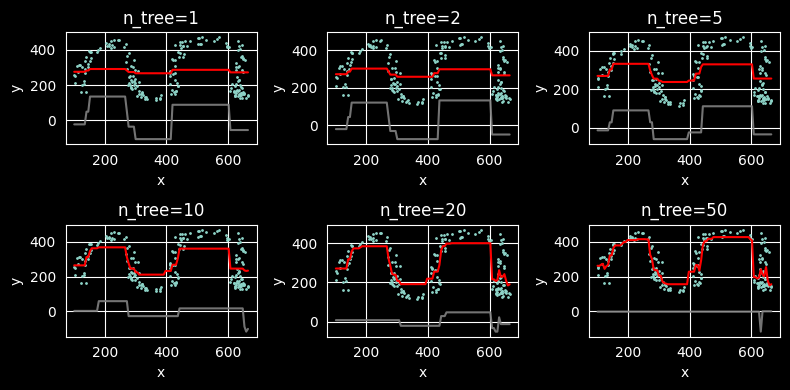

In [51]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree}', s=1)

    clf = GradientBoostingRegressor(n_estimators=n_tree, max_depth=3, random_state=42)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_.flatten()[-1].predict(x)
    ax.plot(x, y, c='grey', alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c='red')

fig.tight_layout()

In [50]:
np.array([[1, 2], [3, 4]]).flatten()

array([1, 2, 3, 4])

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

In [53]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.833


### Hyperparameter Tuning for Boosting Models

1. Domain knowledge -> limits space
2. Random search -> explore globally
3. Grid search -> specify locally
4. Pipeline -> control leakage
5. CV -> stabilize comparisons
6. Multi-metric -> conscious compromises
7. Analyze results -> learn, don't just choose

In [79]:
n_estimators_space = [50, 100, 150, 200, 300]  # model capacity
learning_rate_space = [0.03, 0.05, 0.1]  # jump between the next learning step
max_depth_space = [2, 3]

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score

In [80]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_distributions = {
    'classifier__n_estimators': n_estimators_space,
    'classifier__learning_rate': learning_rate_space,
    'classifier__max_depth': max_depth_space,
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0]
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted')  # 2 * (precision * recall) / (precision + recall)
}

# precision - TP / (TP + FP) (Out of 100 transactions marked as fraud, how many actually were frauds?)
# recall - TP / (TP + FN) (of all the frauds in the data, how many were detected?)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3], 'classifier__n_estimators': [50, 100, ...], 'classifier__subsample': [0.7, 0.8, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f...rage=weighted)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be t

In [44]:
best_params = random_search.best_params_

grid_param_space = {
    'classifier__n_estimators': [
        best_params['classifier__n_estimators'] - 50,
        best_params['classifier__n_estimators'],
        best_params['classifier__n_estimators'] + 50,
    ],
    'classifier__learning_rate': [
        best_params['classifier__learning_rate'] * 0.8,
        best_params['classifier__learning_rate'],
        best_params['classifier__learning_rate'] * 1.2,
    ],
    'classifier__max_depth': [best_params['classifier__max_depth']],
    "classifier__subsample": [best_params["classifier__subsample"]]

}

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_param_space,
    scoring=scoring,
    refit='f1',
    cv=5,n_jobs=-1)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.08000000000000002, 0.1, ...], 'classifier__max_depth': [3], 'classifier__n_estimators': [100, 150, ...], 'classifier__subsample': [0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f...rage=weighted)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"ver

In [50]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    [
        'mean_test_accuracy',
        'mean_test_f1',
        'param_classifier__n_estimators',
        'param_classifier__learning_rate',
        'param_classifier__max_depth',
        'param_classifier__subsample'
    ]
].sort_values('mean_test_f1', ascending=False)

,mean_test_accuracy,mean_test_f1,param_classifier__n_estimators,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__subsample
8,0.833075,0.825744,200,0.12,3,0.8
7,0.832636,0.825003,150,0.12,3,0.8
5,0.832315,0.824828,200,0.10,3,0.8
4,0.832695,0.824701,150,0.10,3,0.8
2,0.832139,0.824236,200,0.08,3,0.8
1,0.832198,0.823950,150,0.08,3,0.8
3,0.831817,0.823043,100,0.10,3,0.8
6,0.831525,0.823008,100,0.12,3,0.8
0,0.831028,0.821639,100,0.08,3,0.8


In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xgboost import XGBRegressor

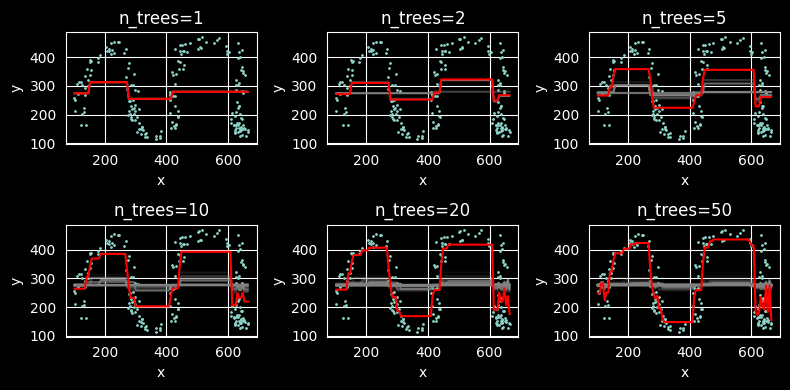

In [57]:
layouts = """
123
456
"""

fig, axs = plt.subplot_mosaic(layouts, figsize=(8, 4))

n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y',ax=ax, title=f'n_trees={n_tree}', s=1)

    rf = XGBRegressor(
        n_estimators=n_tree,
        max_depth=2,
        random_state=42
    )

    rf.fit(data['x'], data['y'])
    x = pd.DataFrame({'x': np.linspace(data.x.min(), data.x.max(), 100)})

    for z, j in enumerate(range(n_tree)):
        y = rf.predict(x, iteration_range=(j, j+1))
        ax.plot(x, y, c='grey', alpha=(z +1) / n_tree)

    y = rf.predict(x)
    ax.plot(x, y, c='red')

plt.tight_layout()

In [58]:
from xgboost import XGBClassifier

In [59]:
X_train.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
dtype: object

In [60]:
y_train=='>50K'

38865    False
17212    False
9312     False
15512    False
23576    False
         ...  
16180     True
42096     True
29457     True
20602    False
4610      True
Name: y, Length: 34189, dtype: bool

In [72]:
model = XGBClassifier(enable_categorical=True)
model.fit(X_train, y_train=='>50K')
accuracy = accuracy_score(y_test=='>50K', model.predict(X_test))
print(f'Model accuracy: {accuracy:.3f}')

Model accuracy: 0.874


In [73]:
from sklearn.metrics import  f1_score

In [74]:
y_proba = model.predict_proba(X_test)[:, 1]


y_pred = (y_proba >= 0.5)
y_pred

array([False, False, False, ..., False, False, False], shape=(14653,))

In [75]:
np.bincount(y_pred)

array([11696,  2957])

In [76]:
f1 = f1_score(y_test=='>50K', model.predict(X_test))
print(f'Model f1 score: {f1:.3f}')

Model f1 score: 0.715


In [77]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test=='>50K', y_pred)

array([[10501,   646],
       [ 1195,  2311]])

In [78]:
model = XGBClassifier(enable_categorical=True, max_depth=3)
model.fit(X_train, y_train=='>50K')
accuracy = accuracy_score(y_test=='>50K', model.predict(X_test))
f1 = f1_score(y_test=='>50K', model.predict(X_test))
print(f'Model accuracy: {accuracy:.3f}')
print(f'Model f1 score: {f1:.3f}')

Model accuracy: 0.877
Model f1 score: 0.718
